# Actividad 3: Reducción de dimensionalidad y clustering
## Análisis de Datos II - CEIA 4B2026

**Dataset:** [Human Activity Recognition Using Smartphones](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones) (UCI).
30 personas realizaron seis actividades cotidianas con un smartphone en la cintura. Cada observación es
una ventana de 2.56 segundos de las señales del acelerómetro y el giroscopio, resumida en 561 features.

**Objetivo:** construir un pipeline no supervisado (estandarización, PCA, clustering) para descubrir qué
estructura tienen esas ventanas sin usar la actividad, y después usar la actividad solo para interpretar
los grupos encontrados.

**Hipótesis de partida**

1. La estructura dominante va a ser la intensidad del movimiento: las ventanas de actividades dinámicas
   (caminar, subir, bajar) y las estáticas (sentado, parado, acostado) deberían separarse casi sin esfuerzo.
2. Dentro de las estáticas, LAYING debería separarse por la orientación de la gravedad (el cuerpo
   horizontal), mientras que SITTING y STANDING, con el tronco vertical y sin movimiento, deberían resultar
   difíciles de distinguir.
3. Dentro de las dinámicas, caminar en llano, subir y bajar escaleras comparten el patrón de marcha:
   esperamos solapamiento, ordenado por intensidad más que por actividad.
4. Una proyección no lineal (UMAP), que preserva vecindarios, debería mostrar esa estructura con más
   nitidez que la proyección lineal de PCA.

**Regla que se respeta en todo el notebook:** la actividad (`y`) no interviene en la estandarización, en
PCA ni en ningún clustering. Aparece recién en la evaluación externa y en la interpretación.

In [1]:
import importlib
import io
import subprocess
import sys
import urllib.request
import warnings
import zipfile
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import HDBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score, silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

EN_COLAB = importlib.util.find_spec('google.colab') is not None
if EN_COLAB and importlib.util.find_spec('umap') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'umap-learn'], check=True)
import umap

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

SEED = 42
DATA_DIR = Path('data/har')
BASE = DATA_DIR / 'UCI HAR Dataset'
URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'

## 1. Dataset y análisis exploratorio

El dataset se descarga de UCI si no está en `data/har/` (60 MB, por eso no se versiona). Se unen las
particiones train y test del original: esa división existe para el problema supervisado y acá no se
entrena ningún clasificador.

In [2]:
def descargar_har(destino: Path, url: str) -> None:
    # El zip de UCI trae adentro otro zip con el dataset; se extrae el interno.
    destino.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(url) as r:
        externo = zipfile.ZipFile(io.BytesIO(r.read()))
    interno = next(n for n in externo.namelist() if n.endswith('.zip'))
    zipfile.ZipFile(io.BytesIO(externo.read(interno))).extractall(destino)

if not (BASE / 'features.txt').exists():
    descargar_har(DATA_DIR, URL)

def cargar_particion(split: str):
    X = pd.read_csv(BASE / split / f'X_{split}.txt', sep=r'\s+', header=None)
    y = pd.read_csv(BASE / split / f'y_{split}.txt', header=None)[0]
    s = pd.read_csv(BASE / split / f'subject_{split}.txt', header=None)[0]
    return X, y, s

nombres = pd.read_csv(BASE / 'features.txt', sep=r'\s+', header=None, names=['i', 'nombre'])['nombre']
repetidos = int(nombres.duplicated().sum())
# Hay nombres repetidos en features.txt (las bandsEnergy): sufijo para que las columnas sean únicas
nombres = nombres + nombres.groupby(nombres).cumcount().map(lambda k: '' if k == 0 else f'__{k + 1}')
actividades = pd.read_csv(BASE / 'activity_labels.txt', sep=r'\s+', header=None, index_col=0)[1]

partes = [cargar_particion(s) for s in ('train', 'test')]
X = pd.concat([p[0] for p in partes], ignore_index=True)
X.columns = nombres
y = pd.concat([p[1] for p in partes], ignore_index=True).map(actividades)
sujeto = pd.concat([p[2] for p in partes], ignore_index=True)

print(f'Ventanas: {len(X):,} ({len(partes[0][0]):,} train + {len(partes[1][0]):,} test) | '
      f'features: {X.shape[1]} | sujetos: {sujeto.nunique()}')
print(f'Valores faltantes: {int(X.isna().sum().sum())} | rango: [{X.values.min():.0f}, {X.values.max():.0f}] | '
      f'nombres de feature repetidos: {repetidos}')
print(f'Ventanas por sujeto: entre {sujeto.value_counts().min()} y {sujeto.value_counts().max()}')
X.iloc[:3, :8]

Ventanas: 10,299 (7,352 train + 2,947 test) | features: 561 | sujetos: 30
Valores faltantes: 0 | rango: [-1, 1] | nombres de feature repetidos: 84
Ventanas por sujeto: entre 281 y 409


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668


In [3]:
dominio = nombres.str[0].map({'t': 'tiempo', 'f': 'frecuencia', 'a': 'ángulo'}).value_counts()
familia = nombres.str.extract(r'^([tf][A-Za-z]+)')[0].value_counts()
estadistico = nombres.str.extract(r'-([a-zA-Z]+)\(\)')[0].value_counts()
print('Dominio de la señal:', dominio.to_dict())
print(f'\nSeñales de las que se calculan features ({len(familia)}):')
print(familia.to_string())
print('\nEstadísticos calculados sobre cada señal:')
print(estadistico.to_string())

Dominio de la señal: {'frecuencia': 289, 'tiempo': 265, 'ángulo': 7}

Señales de las que se calculan features (17):
0
fBodyAccJerk            79
fBodyGyro               79
fBodyAcc                79
tBodyAcc                40
tBodyAccJerk            40
tBodyGyro               40
tBodyGyroJerk           40
tGravityAcc             40
fBodyBodyGyroMag        13
fBodyBodyAccJerkMag     13
fBodyAccMag             13
tBodyGyroMag            13
tBodyGyroJerkMag        13
tBodyAccJerkMag         13
tGravityAccMag          13
tBodyAccMag             13
fBodyBodyGyroJerkMag    13

Estadísticos calculados sobre cada señal:
0
bandsEnergy    126
arCoeff         80
mean            33
std             33
mad             33
max             33
min             33
energy          33
iqr             33
entropy         33
sma             17
correlation     15
meanFreq        13
skewness        13
kurtosis        13


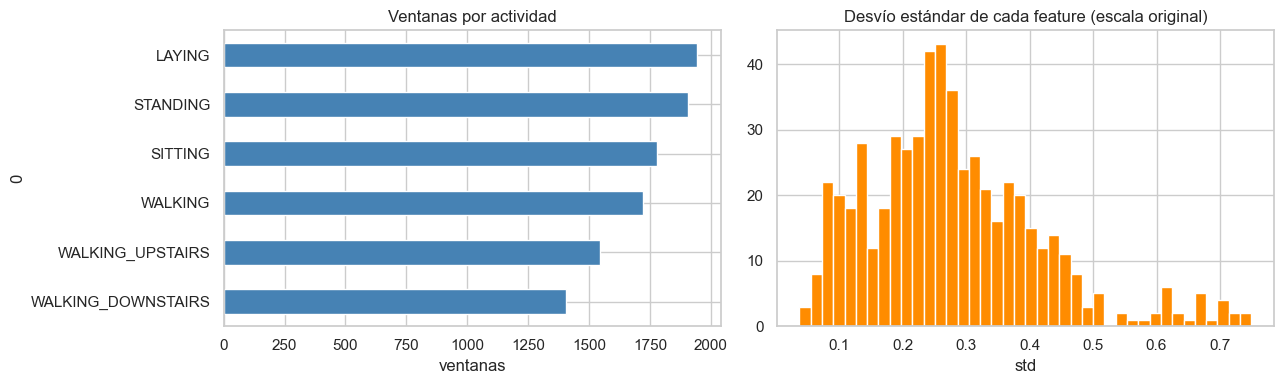

0
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406

std por feature: mínimo 0.037, mediana 0.263, máximo 0.749


In [4]:
desvios = X.std()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
y.value_counts().sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Ventanas por actividad')
axes[0].set_xlabel('ventanas')
axes[1].hist(desvios, bins=40, color='darkorange')
axes[1].set_title('Desvío estándar de cada feature (escala original)')
axes[1].set_xlabel('std')
plt.tight_layout()
plt.show()
print(y.value_counts().to_string())
print(f'\nstd por feature: mínimo {desvios.min():.3f}, mediana {desvios.median():.3f}, máximo {desvios.max():.3f}')

### Lectura del dataset

**Qué representa cada observación.** Una ventana de 2.56 segundos (128 lecturas a 50 Hz, con 50% de
solapamiento) de una persona haciendo una actividad. El dataset no trae la señal cruda sino 561 features
ya calculadas sobre ella: 265 en el dominio del tiempo (`t...`), 289 en el de la frecuencia (`f...`, vía
FFT) y 7 ángulos entre vectores medios. Son estadísticos (media, desvío, máximo, entropía, energía por
bandas, coeficientes autorregresivos) de 17 señales derivadas: aceleración corporal, aceleración de la
gravedad, giroscopio, sus jerks y sus magnitudes. Todas son numéricas; no hay categóricas, imágenes ni
texto, así que no hace falta construir una representación.

**Balance y sujetos.** 10,299 ventanas de 30 personas, entre 281 y 409 por persona, y seis actividades
con entre 1,406 (WALKING_DOWNSTAIRS) y 1,944 (LAYING) ventanas: razonablemente balanceadas.

**Faltantes y escala.** No hay valores faltantes y todas las features vienen normalizadas a [-1, 1].
Eso no las deja comparables entre sí: el desvío estándar va de 0.037 a 0.749 (mediana 0.263). Como PCA
maximiza varianza, sin estandarizar esas veinte veces de diferencia entre features definirían las
componentes por una cuestión de escala y no de estructura. Se aplica `StandardScaler` antes de PCA. Un
detalle de higiene: 84 nombres de features vienen repetidos en `features.txt` (las `bandsEnergy`); se
les agregó un sufijo para que las columnas sean únicas.

## 2. Reducción de dimensionalidad con PCA

561 features para describir 2.56 segundos de movimiento son muchas y, por construcción, redundantes: la
media, el mad, el iqr y el desvío de la misma señal cuentan casi lo mismo. PCA es la herramienta natural
para comprimir esa redundancia de forma lineal y, de paso, ver en qué direcciones varían los datos.

80% de la varianza: 27 componentes
90% de la varianza: 65 componentes
95% de la varianza: 104 componentes
Varianza acumulada con 1, 2, 5, 10 y 50 componentes: 50.7%, 57.0%, 64.0%, 70.2%, 87.1%


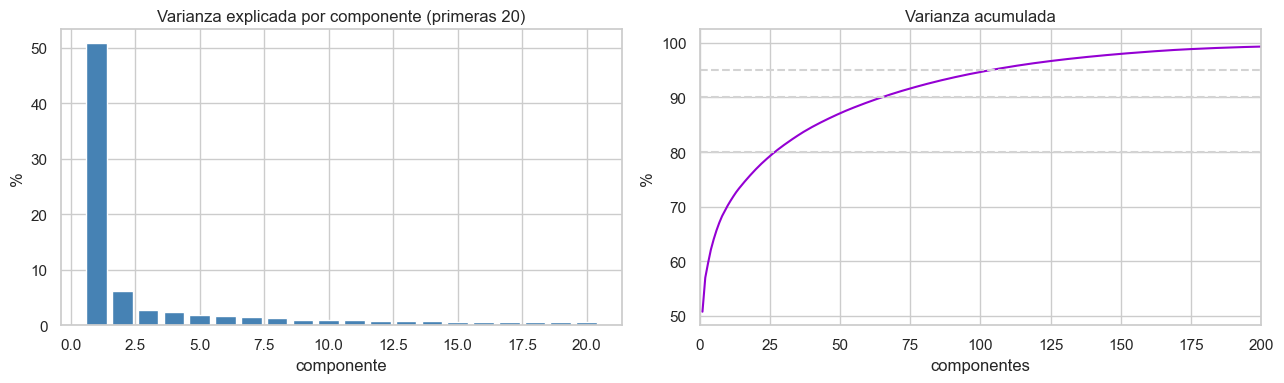

In [5]:
Xs = StandardScaler().fit_transform(X.values)
pca_total = PCA(random_state=SEED).fit(Xs)
acumulada = np.cumsum(pca_total.explained_variance_ratio_)

for umbral in (0.80, 0.90, 0.95):
    print(f'{int(umbral * 100)}% de la varianza: {int(np.searchsorted(acumulada, umbral) + 1)} componentes')
print('Varianza acumulada con 1, 2, 5, 10 y 50 componentes:',
      ', '.join(f'{acumulada[k - 1] * 100:.1f}%' for k in (1, 2, 5, 10, 50)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, 21), pca_total.explained_variance_ratio_[:20] * 100, color='steelblue')
axes[0].set_title('Varianza explicada por componente (primeras 20)')
axes[0].set_xlabel('componente')
axes[0].set_ylabel('%')
axes[1].plot(range(1, len(acumulada) + 1), acumulada * 100, color='darkviolet')
for umbral in (80, 90, 95):
    axes[1].axhline(umbral, ls='--', color='lightgray')
axes[1].set_title('Varianza acumulada')
axes[1].set_xlabel('componentes')
axes[1].set_ylabel('%')
axes[1].set_xlim(0, 200)
plt.tight_layout()
plt.show()

Representación reducida: 65 componentes, 90.0% de la varianza

Mayores cargas de PC1:
fBodyAcc-sma()                0.059
fBodyAccJerk-sma()            0.059
fBodyGyro-sma()               0.059
tBodyAccJerk-sma()            0.059
tBodyAccJerkMag-sma()         0.058
tBodyAccJerkMag-mean()        0.058
fBodyBodyAccJerkMag-sma()     0.058
fBodyBodyAccJerkMag-mean()    0.058

Mayores cargas de PC2:
fBodyAcc-meanFreq()-Z        0.124
tBodyGyroMag-arCoeff()1      0.121
fBodyAccMag-meanFreq()       0.120
tGravityAcc-arCoeff()-Z,1    0.120
tGravityAccMag-arCoeff()1    0.119
tBodyAccMag-arCoeff()1       0.119
tGravityAcc-arCoeff()-Z,2   -0.119
tGravityAcc-arCoeff()-Z,3    0.118

Ventanas con PC1 entre -4 y 4: 1.4%


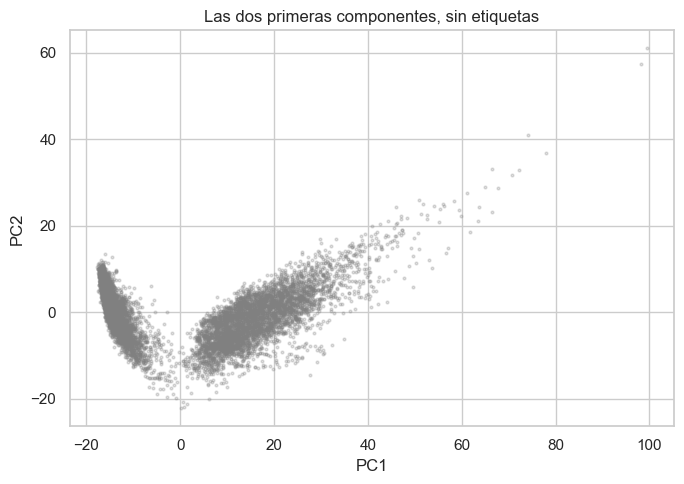

In [6]:
pca = PCA(n_components=0.90, random_state=SEED).fit(Xs)
Xp = pca.transform(Xs)
print(f'Representación reducida: {Xp.shape[1]} componentes, {pca.explained_variance_ratio_.sum() * 100:.1f}% de la varianza')

cargas = pd.DataFrame(pca.components_[:2].T, index=nombres, columns=['PC1', 'PC2'])
for pc in ('PC1', 'PC2'):
    top = cargas[pc].abs().sort_values(ascending=False).head(8).index
    print(f'\nMayores cargas de {pc}:')
    print(cargas.loc[top, pc].round(3).to_string())

# Cuánto del eje principal está "vacío": ventanas en la franja central de PC1
franja = np.mean(np.abs(Xp[:, 0]) < 4) * 100
print(f'\nVentanas con PC1 entre -4 y 4: {franja:.1f}%')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(Xp[:, 0], Xp[:, 1], s=4, alpha=0.25, color='gray')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Las dos primeras componentes, sin etiquetas')
plt.tight_layout()
plt.show()

### Lectura de PCA

**Cuánto se comprime.** La primera componente sola explica el 50.7% de la varianza y las dos primeras el
57.0%. Después la curva se aplana: hacen falta 27 componentes para el 80%, 65 para el 90% y 104 para el
95%. Se retienen 65 componentes (90%): de 561 dimensiones a 65 conservando nueve décimas de la
información. Esa cola larga es la redundancia esperada: cientos de features aportan variaciones chicas y
parcialmente repetidas.

**Qué mide PC1.** Sus mayores cargas son prácticamente iguales (alrededor de 0.06) y se reparten entre
decenas de features del mismo tipo: `sma()` (área de magnitud de la señal) de aceleración, jerk y
giroscopio, y las medias de las magnitudes del jerk. Es un eje de intensidad global del movimiento:
cuánta energía mecánica hay en la ventana, sin importar en qué eje. PC2 carga sobre frecuencias medias
(`meanFreq`) y coeficientes autorregresivos de la gravedad: describe el contenido espectral y la
regularidad de la señal, no su intensidad.

**Lo que ya se ve sin etiquetas.** El scatter PC1 vs PC2 muestra dos masas separadas a lo largo de PC1,
una compacta a la izquierda y otra más dispersa a la derecha, con una franja central casi vacía. Antes
de correr ningún clustering, la hipótesis 1 (movimiento vs reposo como estructura dominante) ya tiene
sustento geométrico.

## 3. Clustering sobre la representación reducida

Se entrenan tres algoritmos con supuestos distintos sobre las 65 componentes de PCA:

- **K-means**: grupos convexos alrededor de centroides, de tamaño parecido. Hay que fijar K.
- **Jerárquico aglomerativo (Ward)**: construye una jerarquía anidada minimizando la varianza interna en
  cada fusión. No exige fijar K de antemano: el dendrograma muestra dónde tiene sentido cortar.
- **HDBSCAN**: basado en densidad. Encuentra la cantidad de grupos por sí solo y marca como ruido lo que
  no pertenece a ninguna zona densa. Es el contraste natural, porque no asume forma ni cantidad.

Para K-means y Ward se barre K de 2 a 10. La silueta (métrica interna, sin etiquetas) se calcula sobre
una muestra fija de 4,000 ventanas, la misma para todas las soluciones, porque con 10,299 puntos la
matriz de distancias completa tiene cien millones de entradas y no agrega precisión. ARI y AMI comparan
cada partición con la actividad real: son evaluación externa, posterior, y no se usan para construir
nada.

silueta            ARI            AMI       
algoritmo K-means   Ward K-means   Ward K-means   Ward
K                                                     
2           0.439  0.438   0.330  0.333   0.545  0.557
3           0.353  0.305   0.332  0.350   0.518  0.548
4           0.181  0.304   0.299  0.344   0.469  0.541
5           0.159  0.123   0.291  0.475   0.460  0.620
6           0.140  0.137   0.420  0.494   0.559  0.622
7           0.119  0.117   0.416  0.484   0.545  0.595
8           0.102  0.083   0.431  0.424   0.554  0.560
9           0.106  0.085   0.424  0.425   0.545  0.557
10          0.108  0.089   0.365  0.425   0.519  0.560

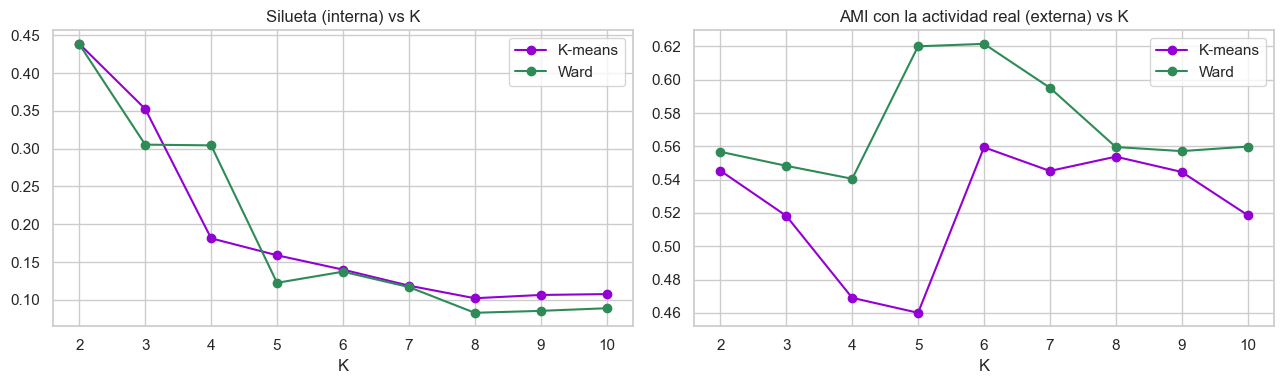

In [7]:
MUESTRA = np.random.RandomState(SEED).choice(len(X), 4000, replace=False)

def evaluar(etiquetas, espacio):
    # Silueta sobre la muestra fija (sin el ruido de HDBSCAN) y acuerdo con la actividad real
    validas = etiquetas != -1
    k = len(np.unique(etiquetas[validas]))
    m = MUESTRA[validas[MUESTRA]]
    return {
        'clusters': k,
        'ruido': int((~validas).sum()),
        'silueta': silhouette_score(espacio[m], etiquetas[m]) if k > 1 else np.nan,
        'ARI': adjusted_rand_score(y, etiquetas),
        'AMI': adjusted_mutual_info_score(y, etiquetas),
    }

Z = linkage(Xp, method='ward')
filas = []
for k in range(2, 11):
    kmeans_k = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(Xp)
    filas.append({'algoritmo': 'K-means', 'K': k, **evaluar(kmeans_k, Xp)})
    filas.append({'algoritmo': 'Ward', 'K': k, **evaluar(fcluster(Z, t=k, criterion='maxclust'), Xp)})
barrido = pd.DataFrame(filas)

tabla = barrido.pivot(index='K', columns='algoritmo', values=['silueta', 'ARI', 'AMI']).round(3)
display(tabla)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for alg, color in (('K-means', 'darkviolet'), ('Ward', 'seagreen')):
    sub = barrido[barrido.algoritmo == alg]
    axes[0].plot(sub.K, sub.silueta, 'o-', color=color, label=alg)
    axes[1].plot(sub.K, sub.AMI, 'o-', color=color, label=alg)
axes[0].set_title('Silueta (interna) vs K')
axes[1].set_title('AMI con la actividad real (externa) vs K')
for ax in axes:
    ax.set_xlabel('K')
    ax.legend()
plt.tight_layout()
plt.show()

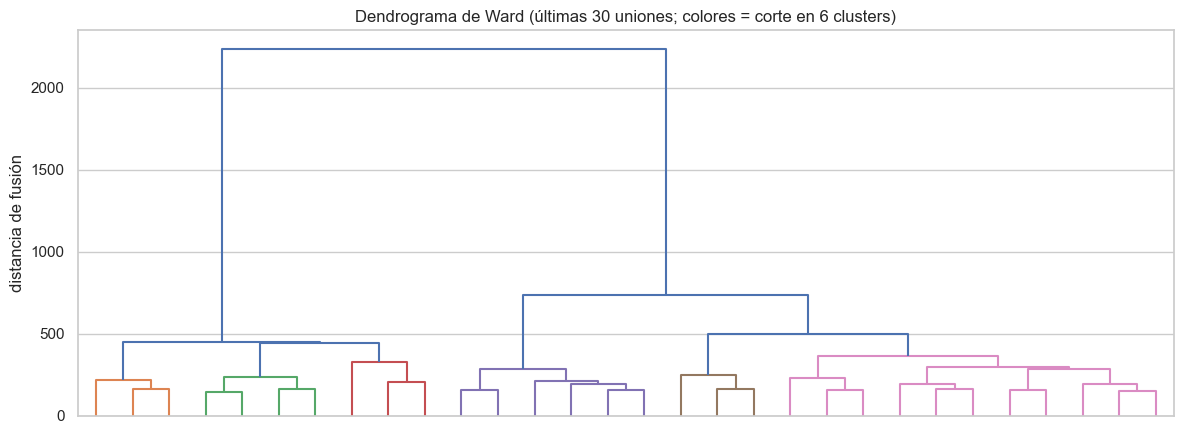

Alturas de las últimas 7 fusiones: [2236.5  737.5  494.8  450.2  441.8  362.9  324.2]
La última fusión es 3.0 veces más alta que la anterior

Anidamiento: qué clusters del corte en 6 caen bajo cada rama del corte en 2
rama K=2        1     2
cluster K=6            
1            1675     0
2             487     0
3            3465     0
4               0  2241
5               0   150
6               0  2281


In [8]:
fig, ax = plt.subplots(figsize=(12, 4.5))
dendrogram(Z, truncate_mode='lastp', p=30, ax=ax, color_threshold=Z[-5, 2], no_labels=True)
ax.set_title('Dendrograma de Ward (últimas 30 uniones; colores = corte en 6 clusters)')
ax.set_ylabel('distancia de fusión')
plt.tight_layout()
plt.show()

alturas = Z[-7:, 2][::-1]
print('Alturas de las últimas 7 fusiones:', np.round(alturas, 1))
print(f'La última fusión es {alturas[0] / alturas[1]:.1f} veces más alta que la anterior')

ward2 = fcluster(Z, t=2, criterion='maxclust')
ward6 = fcluster(Z, t=6, criterion='maxclust')
print('\nAnidamiento: qué clusters del corte en 6 caen bajo cada rama del corte en 2')
print(pd.crosstab(ward6, ward2, rownames=['cluster K=6'], colnames=['rama K=2']))

In [9]:
hdbscan_filas = []
for mcs in (30, 100, 400):
    h = HDBSCAN(min_cluster_size=mcs).fit(Xp)
    hdbscan_filas.append({'min_cluster_size': mcs, **evaluar(h.labels_, Xp)})
hdbscan_pca = pd.DataFrame(hdbscan_filas).round(3)
hdbscan_pca['ruido %'] = (hdbscan_pca['ruido'] / len(X) * 100).round(1)
display(hdbscan_pca)

,min_cluster_size,clusters,ruido,silueta,ARI,AMI,ruido %
0,30,2,3906,0.469,0.263,0.410,37.9
1,100,2,4931,0.466,0.233,0.372,47.9
2,400,2,4953,0.468,0.238,0.377,48.1


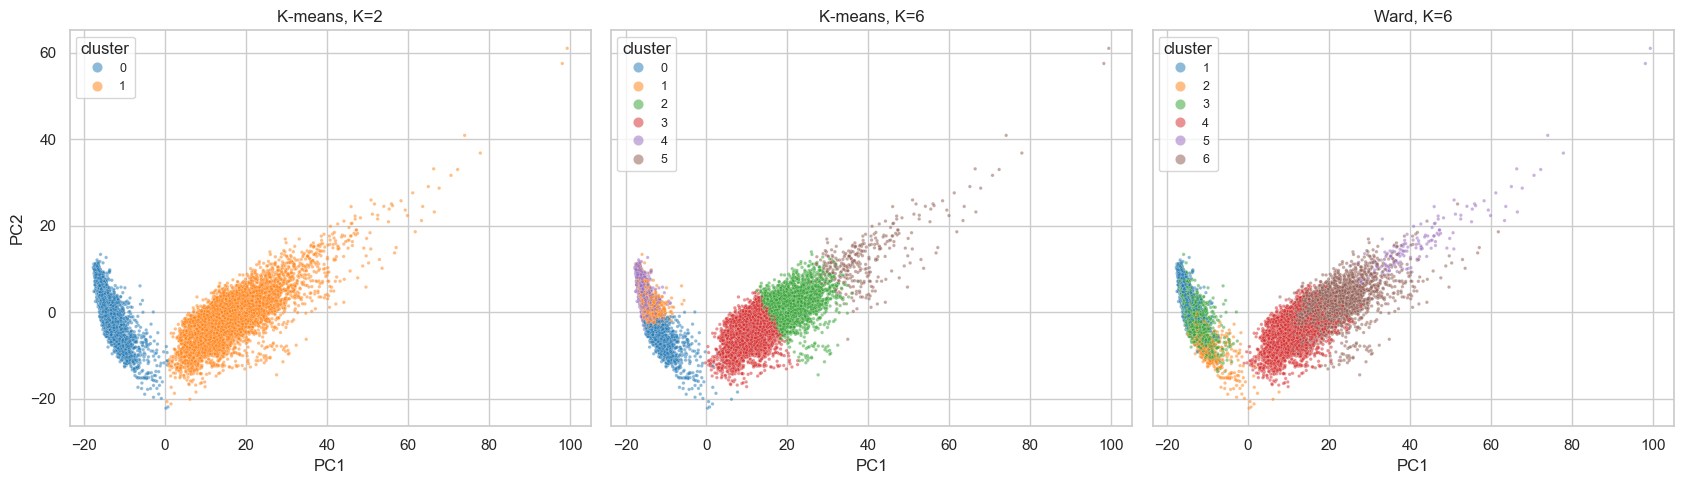

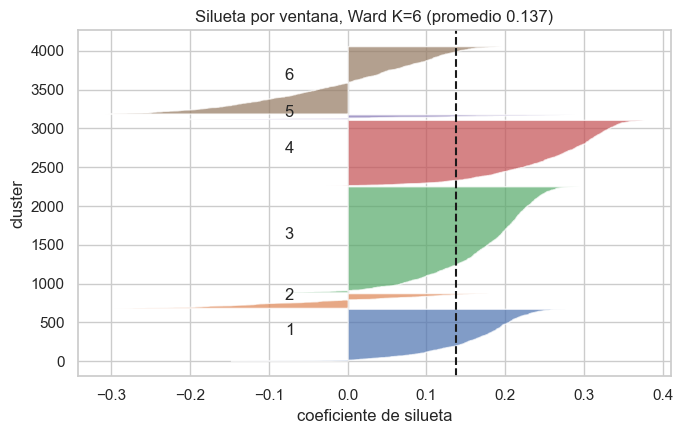

Ventanas con silueta negativa: 14.3%. Por cluster:


,media,negativas_pct,parte_de_las_negativas_pct
cluster,,,
1,0.159,1.647,1.9
2,-0.029,57.592,19.2
3,0.170,1.977,4.7
4,0.256,0.473,0.7
5,0.078,30.000,3.1
6,-0.006,46.260,70.3


In [10]:
kmeans2 = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit_predict(Xp)
kmeans6 = KMeans(n_clusters=6, n_init=10, random_state=SEED).fit_predict(Xp)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
for ax, (titulo, etiquetas) in zip(axes, (('K-means, K=2', kmeans2), ('K-means, K=6', kmeans6), ('Ward, K=6', ward6))):
    sns.scatterplot(x=Xp[:, 0], y=Xp[:, 1], hue=etiquetas, palette='tab10', s=6, alpha=0.5, ax=ax, legend='full')
    ax.set_title(titulo)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(title='cluster', markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

# Silueta por ventana de la solución de Ward, para ver de dónde sale el promedio
vals = silhouette_samples(Xp[MUESTRA], ward6[MUESTRA])
fig, ax = plt.subplots(figsize=(7, 4.5))
y_bajo = 10
for c in np.unique(ward6):
    v = np.sort(vals[ward6[MUESTRA] == c])
    ax.fill_betweenx(np.arange(y_bajo, y_bajo + len(v)), 0, v, alpha=0.7)
    ax.text(-0.08, y_bajo + len(v) / 2, str(c))
    y_bajo += len(v) + 10
ax.axvline(vals.mean(), ls='--', color='k')
ax.set_title(f'Silueta por ventana, Ward K=6 (promedio {vals.mean():.3f})')
ax.set_xlabel('coeficiente de silueta')
ax.set_ylabel('cluster')
plt.tight_layout()
plt.show()

print(f'Ventanas con silueta negativa: {np.mean(vals < 0) * 100:.1f}%. Por cluster:')
sil_df = pd.DataFrame({'cluster': ward6[MUESTRA], 'silueta': vals})
por_cluster = sil_df.groupby('cluster')['silueta'].agg(media='mean', negativas_pct=lambda s: (s < 0).mean() * 100).round(3)
por_cluster['parte_de_las_negativas_pct'] = (sil_df[sil_df.silueta < 0].cluster.value_counts(normalize=True) * 100).round(1)
display(por_cluster)

### Lectura de la comparación y selección

**Lo que dice la silueta.** Para los dos algoritmos el máximo está en K=2 (K-means 0.439, Ward 0.438) y
cae monótonamente: 0.353 en K=3, 0.181 en K=4 y alrededor de 0.14 en K=6 (K-means 0.140, Ward 0.137).
La geometría tiene un único corte fuerte, el de PC1, y todo lo que se agregue después divide masas que
no están separadas por vacíos. El dendrograma lo confirma: la última fusión ocurre a una distancia de
2,236, tres veces la anterior (738), y de ahí hacia abajo las alturas decrecen suavemente (495, 450, 442,
363). El gráfico de silueta por ventana muestra dónde está el problema: el 14.3% de las ventanas tiene
silueta negativa y siete de cada diez de ellas (70%) están en el cluster 6, la masa de
WALKING_DOWNSTAIRS y WALKING encajada entre los clusters 4 y 5 en el continuo de intensidad, con el 46%
de sus propias ventanas en negativo. El cluster 2, el residuo de LAYING, tiene el 58% de sus ventanas en
negativo por la misma razón: está entre 1 y 3. En el otro extremo, el cluster 4 es el mejor definido de
todos (silueta promedio 0.256, 0.5% de negativas), seguido por los dos grandes clusters estáticos.

**Lo que dice HDBSCAN.** Con cualquier tamaño mínimo de cluster (30, 100 o 400) encuentra exactamente
dos grupos y deja entre el 38% y el 48% de las ventanas como ruido. En 65 dimensiones la densidad es
demasiado uniforme para que un método basado en ella distinga algo más que el corte principal: es la
maldición de la dimensionalidad en acción, y una razón de peso para no elegirlo como solución final acá.

**Lo que dice el acuerdo con las actividades.** Con K=2, ARI es bajo (0.33) aunque el corte sea
perfecto, porque ARI penaliza fundir tres actividades en un grupo. A medida que crece K el acuerdo sube
hasta K=5 o 6 y después baja: Ward K=6 llega a ARI 0.494 y AMI 0.622, contra 0.420 y 0.559 de K-means
K=6. Ward es mejor en cada K entre 5 y 7.

**Selección.** Las dos métricas no eligen lo mismo y conviene decir por qué. La silueta responde
"cuántos grupos compactos y separados hay" y su respuesta honesta es dos: movimiento y reposo. Pero esa
estructura ya la dio PC1 y no aporta nada sobre las actividades. La pregunta de dominio es si hay
estructura más fina, y para eso el criterio relevante es cuánta información sobre la actividad recupera
cada partición al K natural del problema. Se elige **Ward con K=6**: mejor acuerdo externo que K-means
al mismo K con la misma silueta, y además una jerarquía anidada que se puede leer: el corte en K=2
separa exactamente las 5,627 ventanas estáticas de las 4,672 dinámicas (tabla de anidamiento, cero
cruces), y los cortes siguientes subdividen cada rama sin mezclarlas.

## 4. Interpretación de los clusters (Ward, K=6)

Recién acá entra la actividad real. Primero la composición de cada cluster y dónde cae cada actividad;
después el perfil físico de cada grupo con seis features interpretables y una ventana representativa (la
más cercana al centroide del cluster en el espacio de PCA).

Composición de cada cluster (% de sus ventanas por actividad)


actividad,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS,n
cluster,,,,,,,
1,95.8,4.2,0.0,0.0,0.0,0.0,1675
2,54.6,30.2,15.2,0.0,0.0,0.0,487
3,2.1,45.0,52.9,0.0,0.0,0.0,3465
4,0.0,0.0,0.0,40.0,6.2,53.9,2241
5,0.0,0.0,0.0,17.3,82.7,0.0,150
6,0.0,0.0,0.0,35.1,50.2,14.8,2281


Dónde cae cada actividad (% de sus ventanas por cluster)


cluster,1,2,3,4,5,6
actividad,,,,,,
LAYING,82.5,13.7,3.8,0.0,0.0,0.0
SITTING,4.0,8.3,87.7,0.0,0.0,0.0
STANDING,0.0,3.9,96.1,0.0,0.0,0.0
WALKING,0.0,0.0,0.0,52.0,1.5,46.5
WALKING_DOWNSTAIRS,0.0,0.0,0.0,9.8,8.8,81.4
WALKING_UPSTAIRS,0.0,0.0,0.0,78.2,0.0,21.8


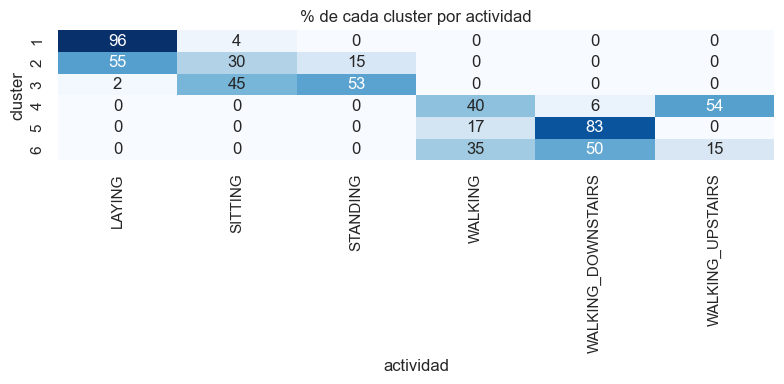

AMI del clustering con la actividad: 0.622 | con el sujeto: 0.050


In [11]:
composicion = pd.crosstab(ward6, y, rownames=['cluster'], colnames=['actividad'], normalize='index').mul(100).round(1)
composicion['n'] = pd.Series(ward6).value_counts().sort_index()
cobertura = pd.crosstab(y, ward6, rownames=['actividad'], colnames=['cluster'], normalize='index').mul(100).round(1)

print('Composición de cada cluster (% de sus ventanas por actividad)')
display(composicion)
print('Dónde cae cada actividad (% de sus ventanas por cluster)')
display(cobertura)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(composicion.drop(columns='n'), annot=True, fmt='.0f', cmap='Blues', cbar=False, ax=ax)
ax.set_title('% de cada cluster por actividad')
plt.tight_layout()
plt.show()
print(f'AMI del clustering con la actividad: {adjusted_mutual_info_score(y, ward6):.3f} | '
      f'con el sujeto: {adjusted_mutual_info_score(sujeto, ward6):.3f}')

In [12]:
RASGOS = {
    'tBodyAccMag-mean()': 'intensidad (magnitud de aceleración corporal)',
    'tBodyAccJerkMag-mean()': 'brusquedad (magnitud del jerk)',
    'tBodyGyroMag-mean()': 'rotación (magnitud del giroscopio)',
    'tGravityAcc-mean()-X': 'gravedad sobre X (eje vertical del cuerpo)',
    'tGravityAcc-mean()-Y': 'gravedad sobre Y',
    'angle(Y,gravityMean)': 'inclinación respecto de la gravedad',
}
rasgos = list(RASGOS)

perfil = X[rasgos].groupby(ward6).mean().round(3)
perfil.insert(0, 'dominante', composicion.drop(columns='n').idxmax(axis=1))
perfil['n'] = composicion['n']
print('Perfil medio de cada cluster (escala original [-1, 1])')
display(perfil)
print('Perfil medio de cada actividad real, para contrastar')
display(X[rasgos].groupby(y).mean().round(3))

def representante(cluster):
    m = ward6 == cluster
    centro = Xp[m].mean(axis=0)
    return np.flatnonzero(m)[np.argmin(((Xp[m] - centro) ** 2).sum(axis=1))]

idx_rep = {c: representante(c) for c in np.unique(ward6)}
representantes = pd.DataFrame({
    'fila': idx_rep,
    'actividad': {c: y[i] for c, i in idx_rep.items()},
    'sujeto': {c: sujeto[i] for c, i in idx_rep.items()},
    **{f: {c: round(X.loc[i, f], 2) for c, i in idx_rep.items()} for f in rasgos},
})
representantes.index.name = 'cluster'
print('Ventana representativa de cada cluster')
display(representantes)

Perfil medio de cada cluster (escala original [-1, 1])


,dominante,tBodyAccMag-mean(),tBodyAccJerkMag-mean(),tBodyGyroMag-mean(),tGravityAcc-mean()-X,tGravityAcc-mean()-Y,"angle(Y,gravityMean)",n
1,LAYING,-0.977,-0.986,-0.970,-0.333,0.650,-0.456,1675
2,LAYING,-0.736,-0.947,-0.760,0.212,0.339,-0.203,487
3,STANDING,-0.967,-0.981,-0.955,0.890,-0.058,0.123,3465
4,WALKING_UPSTAIRS,-0.189,-0.404,-0.281,0.906,-0.222,0.237,2241
5,WALKING_DOWNSTAIRS,0.267,0.254,0.178,0.913,-0.173,0.204,150
6,WALKING_DOWNSTAIRS,0.036,-0.136,-0.144,0.919,-0.213,0.231,2281


Perfil medio de cada actividad real, para contrastar


,tBodyAccMag-mean(),tBodyAccJerkMag-mean(),tBodyGyroMag-mean(),tGravityAcc-mean()-X,tGravityAcc-mean()-Y,"angle(Y,gravityMean)"
0,,,,,,
LAYING,-0.941,-0.979,-0.938,-0.375,0.622,-0.436
SITTING,-0.955,-0.982,-0.947,0.880,0.109,0.006
STANDING,-0.954,-0.977,-0.942,0.941,-0.184,0.210
WALKING,-0.168,-0.241,-0.275,0.935,-0.197,0.219
WALKING_DOWNSTAIRS,0.101,-0.112,-0.130,0.926,-0.169,0.200
WALKING_UPSTAIRS,-0.100,-0.391,-0.178,0.875,-0.281,0.279


Ventana representativa de cada cluster


,fila,actividad,sujeto,tBodyAccMag-mean(),tBodyAccJerkMag-mean(),tBodyGyroMag-mean(),tGravityAcc-mean()-X,tGravityAcc-mean()-Y,"angle(Y,gravityMean)"
cluster,,,,,,,,,
1,408,LAYING,3,-0.99,-0.99,-0.98,-0.33,0.76,-0.53
2,2938,LAYING,16,-0.83,-0.98,-0.72,-0.10,0.43,-0.23
3,4252,SITTING,21,-0.98,-0.99,-0.99,0.97,-0.04,0.11
4,8691,WALKING_UPSTAIRS,12,-0.26,-0.46,-0.37,0.93,-0.25,0.25
5,3923,WALKING,19,0.22,0.32,0.22,0.94,-0.19,0.22
6,8668,WALKING_DOWNSTAIRS,12,-0.09,-0.19,-0.20,0.95,-0.17,0.20


In [13]:
# Qué separa a SITTING de STANDING, las dos actividades que el clustering no distingue
quietas = y.isin(['SITTING', 'STANDING'])
diferencia = X[quietas].groupby(y[quietas]).mean().diff().iloc[-1].abs().sort_values(ascending=False)
print(f'Diferencia mediana entre las medias de SITTING y STANDING sobre las {len(diferencia)} features: {diferencia.median():.3f}')
print(f'Features con diferencia mayor a 0.2: {int((diferencia > 0.2).sum())}')
display(diferencia.head(6).round(3).to_frame('diferencia de medias'))

Diferencia mediana entre las medias de SITTING y STANDING sobre las 561 features: 0.006
Features con diferencia mayor a 0.2: 14


,diferencia de medias
"tGravityAcc-correlation()-X,Y",0.723
"tGravityAcc-correlation()-X,Z",0.463
tGravityAcc-mean()-Y,0.293
fBodyGyro-meanFreq()-X,0.290
tGravityAcc-max()-Y,0.288
tBodyGyro-entropy()-X,0.287


### Lectura de los clusters

**Rama estática (clusters 1, 2 y 3; 5,627 ventanas).**

- **Cluster 1** (1,675 ventanas) es LAYING al 95.8% y reúne el 82.5% de las ventanas de esa actividad.
  Su firma: gravedad sobre el eje X negativa (-0.33) y sobre Y positiva (0.65), es decir el cuerpo
  horizontal, con intensidad mínima (aceleración corporal media -0.98). La ventana representativa es un
  LAYING del sujeto 3 con gravedad X de -0.33.
- **Cluster 3** (3,465 ventanas, el más grande) es SITTING y STANDING a partes casi iguales (45.0% y
  52.9%) y absorbe el 87.7% de las ventanas de SITTING y el 96.1% de las de STANDING. Las dos posturas
  tienen la misma intensidad (-0.97) y la misma gravedad vertical (0.89 sobre X). Sobre las 561 features,
  la diferencia mediana entre las medias de SITTING y STANDING es 0.006; solo las correlaciones de la
  gravedad entre ejes (0.72 en X-Y) y la componente Y de la gravedad (0.29) las distinguen, unas pocas
  features contra cientos que dicen lo mismo. Para un método no supervisado que pondera todas por igual,
  son la misma postura. Hipótesis 2 confirmada en sus dos mitades.
- **Cluster 2** (487 ventanas) es el residuo de la rama: 54.6% LAYING, 30.2% SITTING, 15.2% STANDING.
  Es LAYING imperfecto: gravedad intermedia (0.21 en X), más rotación que el resto del reposo
  (giroscopio -0.76 contra -0.97), ventanas donde la persona se está acomodando o el teléfono quedó
  inclinado. Su representante es un LAYING del sujeto 16 con aceleración corporal -0.83, lejos del -0.99
  del cluster 1.

**Rama dinámica (clusters 4, 5 y 6; 4,672 ventanas).** Acá el clustering no separa actividades sino
niveles de intensidad, como anticipaba la hipótesis 3:

- **Cluster 4** (2,241): el nivel más bajo (aceleración corporal -0.19, jerk -0.40). Es WALKING_UPSTAIRS
  al 53.9% (reúne el 78.2% de esa actividad) más WALKING al 40.0%. Subir escaleras es la marcha más
  lenta y pausada.
- **Cluster 6** (2,281): nivel medio-alto (+0.04). WALKING_DOWNSTAIRS al 50.2% (81.4% de esa actividad)
  más WALKING al 35.1%. Bajar es más brusco: más aceleración de impacto en cada escalón.
- **Cluster 5** (150): el extremo (+0.27, jerk +0.25), 82.7% WALKING_DOWNSTAIRS. Un puñado de las
  ventanas más enérgicas del dataset; su representante es, de hecho, un WALKING rápido del sujeto 19.
- WALKING, la actividad del medio, se parte 52.0% / 46.5% entre los clusters 4 y 6: no tiene un nivel
  de intensidad propio, se reparte entre el de subir y el de bajar.

**Qué estructura captura el clustering y qué no.** Captura actividad y no persona: la información mutua
ajustada con la actividad es 0.622 y con el sujeto 0.05, así que los grupos no son "cada quien con su
forma de moverse". La jerarquía que encuentra es física: primero cuánta energía hay (reposo vs
movimiento), luego la orientación del cuerpo respecto de la gravedad (acostado vs erguido), y por último
el nivel de intensidad de la marcha. Es coherente con el dominio y, al mismo tiempo, muestra el límite de
las features: lo que no cambia ni la energía ni la orientación (sentarse vs pararse) es invisible para un
método no supervisado.

## 5. Visualización e interpretación con UMAP (opcional)

UMAP se aplica a los datos originales estandarizados (las 561 features), no a la salida de PCA.
Preserva vecindarios locales y no distancias globales, así que las distancias entre islas no se leen
literalmente; lo que sí se lee es qué puntos quedan juntos y dónde la nube es densa o rala. Primero el
plano sin etiquetas, que es lo que un análisis no supervisado tiene; después coloreado por actividad para
interpretarlo.

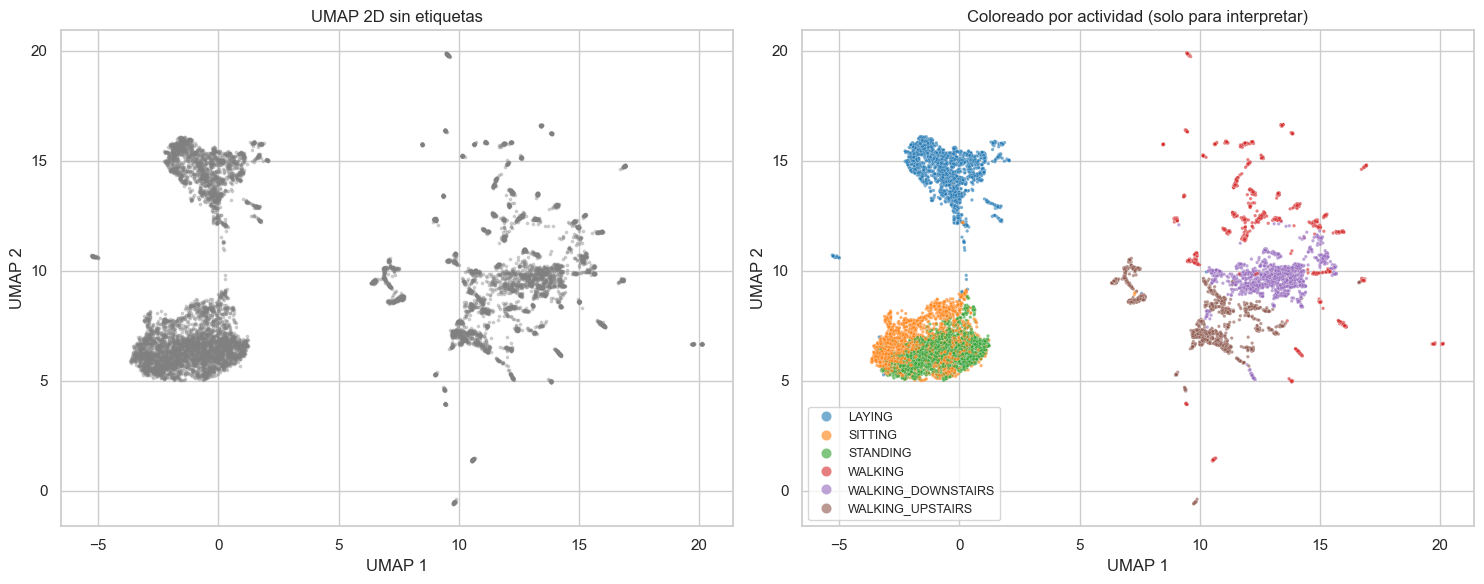

Centroide y dispersión de cada actividad en el plano


,media u1,media u2,std u1,std u2
0,,,,
LAYING,-0.54,14.44,1.33,1.25
SITTING,-1.58,6.80,1.27,1.05
STANDING,-0.83,6.29,1.13,0.63
WALKING,12.78,11.78,2.63,3.78
WALKING_DOWNSTAIRS,13.08,9.64,1.21,1.05
WALKING_UPSTAIRS,9.97,7.63,1.86,1.98


Silueta de las actividades reales en cada representación: original 0.030 | PCA 0.043 | UMAP 0.260


In [14]:
embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED).fit_transform(Xs)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(embedding[:, 0], embedding[:, 1], s=3, alpha=0.3, color='gray')
axes[0].set_title('UMAP 2D sin etiquetas')
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y, hue_order=sorted(y.unique()), palette='tab10',
                s=6, alpha=0.6, ax=axes[1])
axes[1].set_title('Coloreado por actividad (solo para interpretar)')
axes[1].legend(markerscale=3, fontsize=9)
for ax in axes:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

plano = pd.DataFrame(embedding, columns=['u1', 'u2'])
print('Centroide y dispersión de cada actividad en el plano')
display(pd.concat([plano.groupby(y).mean().round(2).add_prefix('media '), plano.groupby(y).std().round(2).add_prefix('std ')], axis=1))
print('Silueta de las actividades reales en cada representación: '
      f'original {silhouette_score(Xs[MUESTRA], y.iloc[MUESTRA]):.3f} | '
      f'PCA {silhouette_score(Xp[MUESTRA], y.iloc[MUESTRA]):.3f} | '
      f'UMAP {silhouette_score(embedding[MUESTRA], y.iloc[MUESTRA]):.3f}')

HDBSCAN sobre el plano UMAP: 7 clusters, 1,195 ventanas de ruido, silueta 0.623, ARI 0.586, AMI 0.714


actividad,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS,n
cluster (-1 = ruido),,,,,,,
-1,4.7,0.0,0.0,79.2,5.1,11.0,1195
0,0.3,48.0,51.8,0.0,0.0,0.0,3683
1,99.6,0.4,0.0,0.0,0.0,0.0,1883
2,0.0,0.0,0.0,52.6,0.0,47.4,114
3,0.3,0.8,0.0,0.3,0.0,98.7,381
4,0.0,0.0,0.0,99.0,1.0,0.0,102
5,0.0,0.0,0.0,6.2,54.1,39.6,2477
6,0.0,0.0,0.0,99.4,0.6,0.0,464


% de las ventanas de cada actividad que quedan como ruido (baja densidad)


,ruido %
0,
LAYING,2.9
SITTING,0.0
STANDING,0.0
WALKING,54.9
WALKING_DOWNSTAIRS,4.3
WALKING_UPSTAIRS,8.5


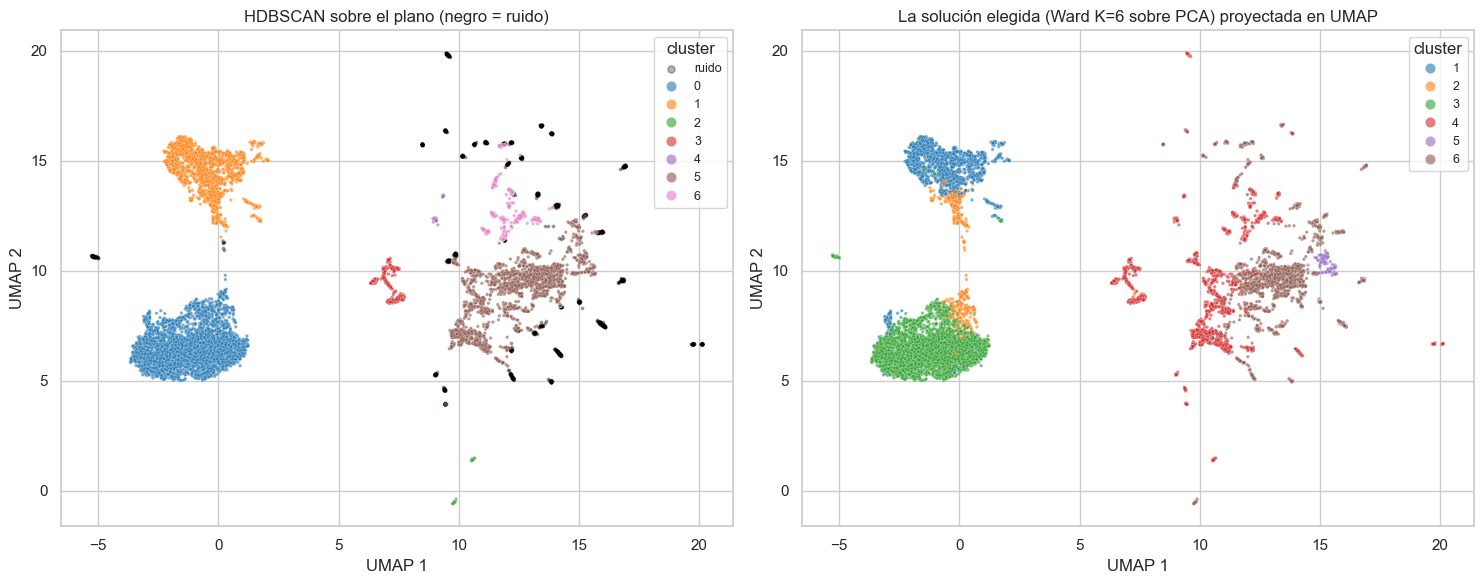

In [15]:
# Densidad en el plano: el mismo HDBSCAN que en 65 dimensiones no encontraba nada
hdb_umap = HDBSCAN(min_cluster_size=100).fit(embedding)
etiquetas_umap = hdb_umap.labels_
res_umap = evaluar(etiquetas_umap, embedding)
print(f"HDBSCAN sobre el plano UMAP: {res_umap['clusters']} clusters, {res_umap['ruido']:,} ventanas de ruido, "
      f"silueta {res_umap['silueta']:.3f}, ARI {res_umap['ARI']:.3f}, AMI {res_umap['AMI']:.3f}")

comp_umap = pd.crosstab(etiquetas_umap, y, rownames=['cluster (-1 = ruido)'], colnames=['actividad'], normalize='index').mul(100).round(1)
comp_umap['n'] = pd.Series(etiquetas_umap).value_counts().sort_index()
display(comp_umap)
print('% de las ventanas de cada actividad que quedan como ruido (baja densidad)')
display((pd.Series(etiquetas_umap == -1).groupby(y).mean() * 100).round(1).to_frame('ruido %'))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ruido = etiquetas_umap == -1
axes[0].scatter(embedding[ruido, 0], embedding[ruido, 1], s=3, color='black', alpha=0.3, label='ruido')
sns.scatterplot(x=embedding[~ruido, 0], y=embedding[~ruido, 1], hue=etiquetas_umap[~ruido], palette='tab10', s=6, alpha=0.6, ax=axes[0])
axes[0].set_title('HDBSCAN sobre el plano (negro = ruido)')
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=ward6, palette='tab10', s=6, alpha=0.6, ax=axes[1])
axes[1].set_title('La solución elegida (Ward K=6 sobre PCA) proyectada en UMAP')
for ax in axes:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(title='cluster', markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

### Lectura de UMAP

**Regiones.** El plano muestra tres zonas: una isla aislada en la parte superior, un bloque denso debajo
de ella y una región extendida a la derecha. Coloreando por actividad, la isla superior es LAYING
(centroide en UMAP 2 de 14.4), el bloque denso es SITTING y STANDING superpuestos (UMAP 2 entre 6.3 y
6.8, con STANDING como la clase más compacta de todas, desvíos 1.1 y 0.6), y la región derecha son las
tres marchas (UMAP 1 entre 10 y 13).

**Densidad y puntos aislados.** HDBSCAN sobre el plano, que en 65 dimensiones no encontraba nada,
acá recorta siete grupos: SITTING y STANDING juntos (3,683 ventanas, 48/52), LAYING puro (1,883,
99.6%), un lóbulo de WALKING_UPSTAIRS casi puro (381, 98.7%), dos islas chicas de WALKING puro (102 y
464) y una masa mixta de bajar y subir (2,477: 54% DOWNSTAIRS, 40% UPSTAIRS). Los puntos aislados
(ruido, 1,195) son WALKING en un 79%: el 54.9% de las ventanas de caminar en llano caen en zonas de baja
densidad, contra 0% de SITTING y STANDING y 2.9% de LAYING. Caminar es la actividad más heterogénea en
el espacio de los sensores (su dispersión en el plano, 2.6 y 3.8, duplica la de cualquier otra), lo que
es razonable: en llano cada persona impone su ritmo, en una escalera el escalón impone la cadencia.

**Qué agrega frente a PCA.** La silueta de las actividades reales pasa de 0.030 en el espacio original y
0.043 en PCA a 0.260 en UMAP: la estructura no lineal es mucho más nítida que lo que una proyección
lineal puede mostrar, y lo confirma que el mismo HDBSCAN alcanza ARI 0.586 y AMI 0.714 contra 0.494 y
0.622 de la solución elegida. Con un matiz: UMAP deforma las distancias globales, así que esas siluetas
no son comparables con las de la sección 3 y el clustering sobre el plano se usa como contraste, no como
pipeline principal. Lo que sí deja claro, y es la conclusión más útil de la sección: el solapamiento de
SITTING y STANDING no es un artefacto de la linealidad de PCA, sobrevive a una proyección no lineal.
LAYING y subir escaleras, en cambio, sí tienen forma propia. Hipótesis 4 confirmada con esa salvedad.

## 6. Conclusiones

**Estructura de los datos.** Las 561 features son muy redundantes: 65 componentes de PCA conservan el
90% de la varianza y una sola, la intensidad del movimiento, explica el 50.7%. Esa es también la única
frontera nítida que tienen los datos: cualquier algoritmo encuentra el corte reposo/movimiento (Ward lo
hace sin un solo error sobre 10,299 ventanas) y ninguno encuentra fronteras comparables después.

**Las seis actividades no son seis grupos.** Son tres niveles de una jerarquía física: energía, luego
orientación respecto de la gravedad, luego intensidad de la marcha. LAYING tiene forma propia (95.8% de
pureza); SITTING y STANDING son indistinguibles sin etiquetas (un cluster 45/53, diferencia mediana de
0.006 entre sus perfiles); las tres marchas se ordenan en un continuo de intensidad donde subir escaleras
es lo más lento, bajar lo más brusco y caminar en llano se reparte entre ambos.

**Elección del método.** La silueta prefiere K=2 y el acuerdo con las actividades prefiere K=5 o 6; se
eligió Ward con K=6 (ARI 0.494, AMI 0.622) porque responde la pregunta de dominio y su jerarquía es
legible. HDBSCAN quedó descartado en 65 dimensiones por la maldición de la dimensionalidad (dos grupos y
hasta 48% de ruido), aunque sobre el plano de UMAP funciona bien (ARI 0.586). La lección es que la
métrica adecuada depende de la pregunta, y que la densidad necesita un espacio donde exista.

**Para el problema.** Un sistema que necesite distinguir sentado de parado no lo va a lograr con
clustering sobre estas features: requiere supervisión o features específicas de la inclinación (las
pocas que difieren). En cambio, detectar reposo vs movimiento y acostado vs erguido se puede hacer sin
una sola etiqueta, y caminar en llano es la actividad que más varía entre personas, lo que conviene tener
en cuenta al modelarla.